# Imports and data/model preparation

In [7]:
from config import PROCESSED_DATA_DIR, CSV_DATA_DIR, MODELS_DIR, DEVICE, PROJ_ROOT, BATCH_SIZE_TRANSFORMER
from script.trainer import Trainer, EarlyStopping
from models.SwinTransformer import SwinRegressor
import torch
from torch.utils.data import DataLoader
from script.dataset import MapDataset
from torch.optim import AdamW
from script.visualization import plot_history
import pandas as pd
from script.cross_validation import kfoldCV
import optuna
import joblib
from collections import defaultdict

## Visualize study parameters

In [8]:
study_file = PROJ_ROOT / 'studies/SwinRegressor_study'
study : optuna.Study = joblib.load(study_file, 'r')

In [9]:
(df := study.trials_dataframe())[df['state'] == 'COMPLETE']

,number,value,datetime_start,datetime_complete,duration,params_backbone_LR,params_dropout,params_head_LR,params_head_layer_1,params_head_layer_2,params_num_layers,params_weight_decay,system_attrs_completed_rung_0,system_attrs_completed_rung_1,state
0,0,0.039826,2025-08-04 20:02:12.158668,2025-08-04 20:26:23.010436,0 days 00:24:10.851768,0.000108,0.2,0.000027,256,256.0,2,0.000210,0.049372,0.044108,COMPLETE
1,1,0.058128,2025-08-04 20:26:25.108185,2025-08-04 20:50:29.995983,0 days 00:24:04.887798,0.000001,0.5,0.000004,1024,NaN,1,0.158401,0.055383,NaN,COMPLETE
2,2,0.041103,2025-08-04 20:50:32.689785,2025-08-04 21:14:38.104523,0 days 00:24:05.414738,0.000016,0.4,0.000600,1024,NaN,1,0.020449,0.041606,0.041519,COMPLETE
3,3,0.002744,2025-08-04 21:14:40.883866,2025-08-04 21:38:57.293840,0 days 00:24:16.409974,0.000249,0.0,0.007994,128,1024.0,2,0.001201,0.003760,0.005456,COMPLETE
6,6,0.043197,2025-08-04 21:47:35.129871,2025-08-04 22:11:42.285226,0 days 00:24:07.155355,0.000079,0.5,0.002340,256,NaN,1,0.026879,0.046981,NaN,COMPLETE
8,8,0.002438,2025-08-04 22:21:43.985207,2025-08-04 22:45:57.955037,0 days 00:24:13.969830,0.000151,0.0,0.007293,128,1024.0,2,0.000339,0.003403,0.003386,COMPLETE
11,11,0.042670,2025-08-04 22:54:37.181693,2025-08-04 23:18:46.704649,0 days 00:24:09.522956,0.000837,0.0,0.004357,128,1024.0,2,0.000785,0.040322,NaN,COMPLETE
12,12,0.002857,2025-08-04 23:18:50.051000,2025-08-04 23:43:09.561896,0 days 00:24:19.510896,0.000041,0.0,0.003643,128,1024.0,2,0.000015,0.002782,NaN,COMPLETE
14,14,0.003151,2025-08-04 23:53:17.617078,2025-08-05 00:17:37.161680,0 days 00:24:19.544602,0.000065,0.0,0.003087,128,NaN,1,0.001947,0.003611,NaN,COMPLETE
15,15,0.002349,2025-08-05 00:17:40.650874,2025-08-05 00:42:02.106030,0 days 00:24:21.455156,0.000045,0.0,0.005127,128,1024.0,2,0.009817,0.004260,0.003337,COMPLETE


In [10]:
params = study.best_params
print(params)

{'backbone_LR': 4.5105938802575144e-05, 'head_LR': 0.005127003295401714, 'weight_decay': 0.009817479780648609, 'head_layer_1': 128, 'num_layers': 2, 'head_layer_2': 1024, 'dropout': 0.0}


In [11]:
optuna.visualization.plot_timeline(study)

## Prepare data and model for training

In [12]:
df_train = pd.read_csv(str(CSV_DATA_DIR / 'df_train.csv'))
df_val = pd.read_csv(str(CSV_DATA_DIR / 'df_valid.csv'))
df_test = pd.read_csv(str(CSV_DATA_DIR / 'df_test.csv'))

In [13]:
train_ds = MapDataset(PROCESSED_DATA_DIR / 'train', df_train, task='regression', augment=True)
val_ds = MapDataset(PROCESSED_DATA_DIR / 'valid', df_val, task='regression')
test_ds = MapDataset(PROCESSED_DATA_DIR / 'test', df_test, task='regression')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE_TRANSFORMER, shuffle=True, num_workers=8)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE_TRANSFORMER, num_workers=8)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE_TRANSFORMER, num_workers=8)

In [14]:
head_cfg = {
    'hidden_dims' : [128, 1024],
    'dropout_rate': params['dropout']
}
model = SwinRegressor(img_size=224, head_cfg=head_cfg)

loss = torch.nn.MSELoss()
ES = EarlyStopping(patience=5, restore_best_weights=True)

optim = AdamW([
    {'params': model.MLP.parameters(), 'lr': params['head_LR'], "weight_decay": params['weight_decay']},
    {'params': model.backbone.parameters(), 'lr': params['backbone_LR']}
])

EPOCHS = 15

for param in model.backbone.parameters():
    param.require_grad = True

trainer = Trainer(model, optim, loss)

#scheduler = torch.optim.lr_scheduler.MultiStepLR(optim, milestones=[10, 20], gamma=0.05)
#trainer.set_scheduler(scheduler)

### Compute CV loss

In [15]:
CVLoss = kfoldCV(
    trainer, 
    train_ds, 
    num_folds=5, 
    epochs=15, 
    batch_size=BATCH_SIZE_TRANSFORMER, 
    task="regression", 
    ES=ES
)

print(f"k-Fold CV loss: {CVLoss:.5f}")


Epoch 1/15:   0%|          | 0/361 [00:00<?, ?it/s]

Starting fold 1/5


Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]


Epoch 2/15:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]


Epoch 7/15:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/91 [00:00<?, ?it/s]

Fold 5/5 ended with loss: 0.0085
5-fold CV loss: 0.0072
k-Fold CV loss: 0.00717


## Train classifier

In [16]:
trainer.reset_training()
trainer.train(train_loader, val_loader, 'regression', epochs=EPOCHS, early_stopping=ES)


Epoch 1/15:   0%|          | 0/451 [00:00<?, ?it/s]

[1/15] Train Loss: 0.0402


Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

[1/15] Val Loss: 0.0059 



Epoch 2/15:   0%|          | 0/451 [00:00<?, ?it/s]

...

[6/15] Val Loss: 0.0031 



Epoch 7/15:   0%|          | 0/451 [00:00<?, ?it/s]

[7/15] Train Loss: 0.0024


Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

[7/15] Val Loss: 0.0044 
Stopping training due to EarlyStopping


/home/aislab/princisgh_map_completeness/map_completeness_estimation/src/script/visualization.py:26: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



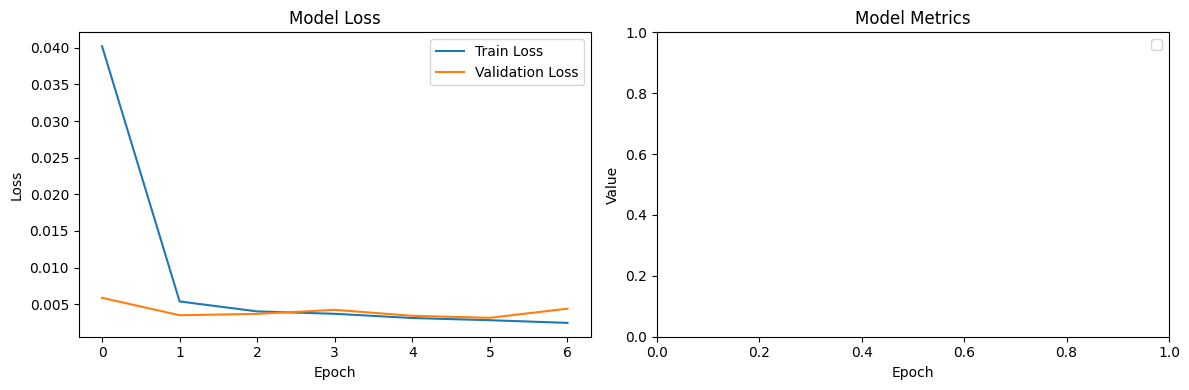

In [17]:
plot_history(trainer.history)

#### Validation Results

In [18]:
trainer.evaluate(val_loader) # run evaluation in case early stop was triggered
trainer.save_model(MODELS_DIR, 'SwinRegressor.pt')

Evaluation:   0%|          | 0/104 [00:00<?, ?it/s]

Model SwinRegressor_regression.pt saved to /home/aislab/princisgh_map_completeness/map_completeness_estimation/model_weights


# Test result and metrics

In [19]:
import torch.nn as nn

y_hat, y_true, loss = trainer.predict(test_loader)
y_hat, y_true = y_hat.squeeze(), y_true.squeeze()

# map filenames are expected in the format 'id@run@time'
env_id = lambda x: x.split('@')[0]
result_dict = defaultdict(list)
for i in range(len(test_ds)):
    mapname = test_ds.df['id'].iloc[i] 
    result_dict[env_id(mapname)].append(abs(y_hat[i] - y_true[i])) # store the absolute prediction error, grouped by map

average_errors = [(id, sum(lst) / len(lst)) for id, lst in result_dict.items()]

Evaluation:   0%|          | 0/95 [00:00<?, ?it/s]

W0806 14:15:39.252000 342826 torch/_dynamo/convert_frame.py:964] [16/8] torch._dynamo hit config.recompile_limit (8)
W0806 14:15:39.252000 342826 torch/_dynamo/convert_frame.py:964] [16/8]    function: 'torch_dynamo_resume_in_make_flat_list_of_images_at_244' (/home/aislab/princisgh_map_completeness/map_completeness_estimation/.venv/lib/python3.12/site-packages/transformers/image_utils.py:244)
W0806 14:15:39.252000 342826 torch/_dynamo/convert_frame.py:964] [16/8]    last reason: 16/2: len(images) == 32                                      
W0806 14:15:39.252000 342826 torch/_dynamo/convert_frame.py:964] [16/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0806 14:15:39.252000 342826 torch/_dynamo/convert_frame.py:964] [16/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.
W0806 14:15:39.255000 342826 torch/_dynamo/convert_frame.py:964] [22/8] torch._dynamo hit config.recompile_limit (8)
W0806 14:15:39.255000 342

In [20]:
print("Map completeness percentage prediction results")
for env, err in average_errors:
    print(f"{env:>40} -> {float(err)*100:.2f}%")
print(f"\nAverage: {sum([x[1] for x in average_errors]) / len(average_errors)*100:.2f}%")

Map completeness percentage prediction results
                                     8-1 -> 3.09%
                                   E18-1 -> 5.39%
                                   E60-1 -> 3.75%
                      MediaCache_updated -> 2.35%
                          Rustic_updated -> 0.92%
                       Vipiteno2_updated -> 5.83%
                                    W8-1 -> 3.85%
         ZELLENBOROS_GRUPPENZONE_updated -> 3.78%
                       autoSales_updated -> 0.83%
                                   lab_a -> 5.91%
                                   lab_f -> 3.65%
      modern-office-floor-plan-1_updated -> 2.62%
                                office_b -> 3.90%
 scuola_secondaria_i_grado_mera__updated -> 1.29%
         south_mountain_school_1_updated -> 3.91%

Average: 3.41%
